# 03 — Vertex Convolution with Hyper-SAGNN

This notebook runs the **Hyper-SAGNN V2E2V** convolution layer (`dhgnn_lib.hypersagnn.HyperSAGNNLayer`) over the real `H_aug(t)` hypergraph and node features built in notebooks 01-02.

Each layer:

1. **V2E** — pools member-cell embeddings into a representation per hyperedge, using a static/dynamic-embedding attention score (the Hyper-SAGNN idea).
2. **E2V** — every cell attends back over the hyperedges it belongs to (weighted by an edge-type embedding and the hyperedge weight) and updates its own embedding.

We inspect the embeddings (via PCA) and the learned attention weights, both for a single layer and for a 3-layer `DynamicHypergraphStack` (the backbone used inside the full `DHGNNModel` in notebook 04).

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath('..'))

from dhgnn_lib.cell_universe import CellUniverse
from dhgnn_lib import hyperedges, incidence, node_features, labels, visualization
from dhgnn_lib.hypersagnn import HyperSAGNNLayer
from dhgnn_lib.dhgnn_model import DynamicHypergraphStack

RAW_DIR = '../raw_dataset'
OUTPUT_DIR = '../output_tables'
torch.manual_seed(0)

universe = CellUniverse.build(RAW_DIR, OUTPUT_DIR)
nfb = node_features.NodeFeatureBuilder(RAW_DIR, universe)
store = hyperedges.HyperedgeStore(RAW_DIR, OUTPUT_DIR, universe)
print(f'N={len(universe)} cells, F={nfb.num_features} features')


N=1625 cells, F=10 features


## 1. Build `H_aug(t)` and `X(t)` for a sample timepoint

In [2]:
T_SAMPLE = 100
spatial = store.spatial(T_SAMPLE)
batch = incidence.assemble(len(universe), spatial, store.lineage(), store.functional())
x = nfb.build(T_SAMPLE)
present = x[:, 5].bool()
fate = labels.fate_labels(universe)
print(f'X(t={T_SAMPLE}) shape {tuple(x.shape)}, H_aug edges {batch.num_edges}, present cells {int(present.sum())}')

X(t=100) shape (1625, 10), H_aug edges 5105, present cells 317


## 2. Single Hyper-SAGNN layer (untrained, random init)

Even with random weights, the V2E2V layer mixes information across hyperedges; training (notebook 04) is what shapes these embeddings into useful representations.

In [3]:
HIDDEN_DIM = 32
input_proj = torch.nn.Sequential(
    torch.nn.Linear(nfb.num_features, HIDDEN_DIM), torch.nn.GELU(), torch.nn.LayerNorm(HIDDEN_DIM)
)
layer = HyperSAGNNLayer(HIDDEN_DIM)

h0 = input_proj(x)
with torch.no_grad():
    h1, attn = layer(h0, batch, return_attention=True)
print(f'h0 {tuple(h0.shape)} -> h1 {tuple(h1.shape)}')
print(f'v2e_attn {tuple(attn["v2e_attn"].shape)}, e2v_attn {tuple(attn["e2v_attn"].shape)}')


h0 (1625, 32) -> h1 (1625, 32)
v2e_attn (15336,), e2v_attn (15336,)


### Embeddings before vs. after one Hyper-SAGNN layer (PCA, coloured by founder lineage)

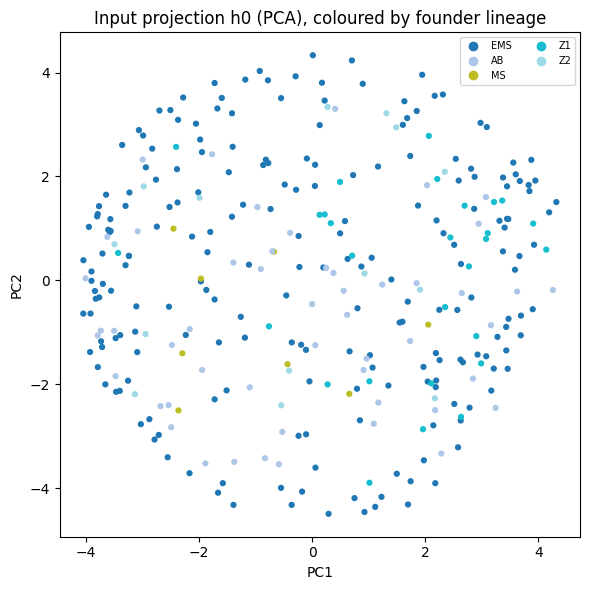

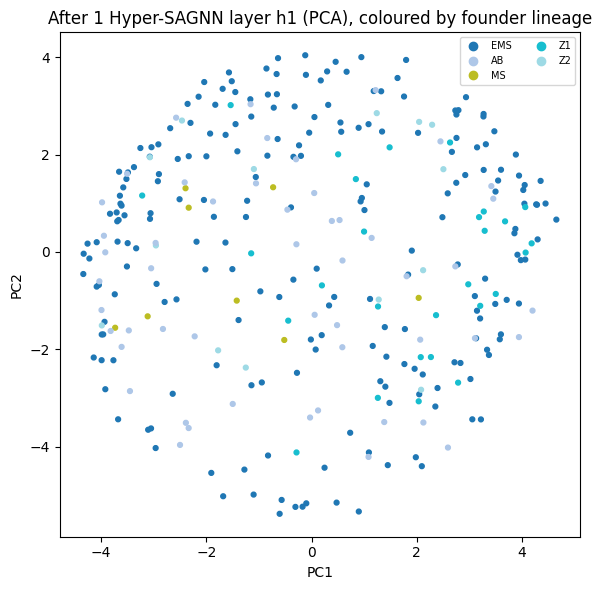

In [4]:
fig = visualization.plot_embeddings_pca(
    h0[present], fate[present].numpy(), label_names=labels.FATE_NAMES,
    title='Input projection h0 (PCA), coloured by founder lineage',
)
plt.show()

fig = visualization.plot_embeddings_pca(
    h1[present], fate[present].numpy(), label_names=labels.FATE_NAMES,
    title='After 1 Hyper-SAGNN layer h1 (PCA), coloured by founder lineage',
)
plt.show()


## 4. 3-layer `DynamicHypergraphStack` (untrained)

The backbone used inside `DHGNNModel`: 3 stacked Hyper-SAGNN layers. With `recluster=False` (used here) the hypergraph `H_aug(t)` is fixed across layers; `recluster=True` (used during training in notebook 04) rebuilds the spatial block from the embeddings produced by each layer.

After 3-layer stack: (1625, 32)


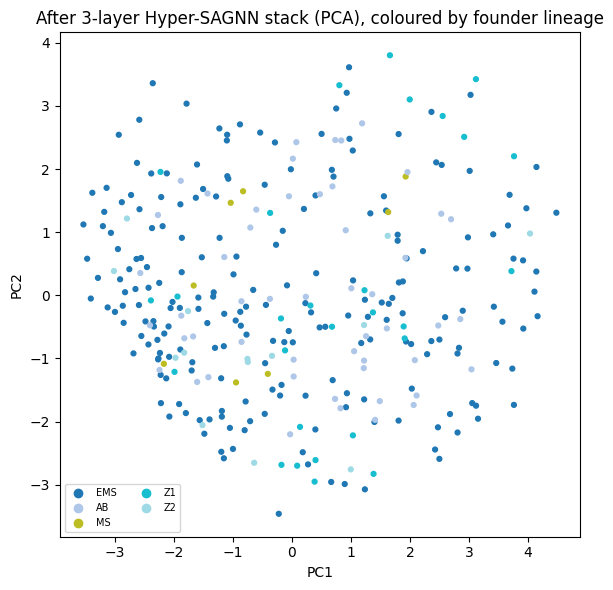

In [5]:
stack = DynamicHypergraphStack(HIDDEN_DIM, num_layers=3)
with torch.no_grad():
    h_stack = stack(h0, batch)
print(f'After 3-layer stack: {tuple(h_stack.shape)}')

fig = visualization.plot_embeddings_pca(
    h_stack[present], fate[present].numpy(), label_names=labels.FATE_NAMES,
    title='After 3-layer Hyper-SAGNN stack (PCA), coloured by founder lineage',
)
plt.show()


## Summary

- `HyperSAGNNLayer` implements V2E2V message passing with a static/dynamic-embedding attention score, edge-type embeddings, and per-hyperedge scalar weights.
- A 3-layer `DynamicHypergraphStack` runs end-to-end on the real `H_aug(t)` for N≈1625 cells and ~5000+ hyperedges.
- Next: **notebook 04** wraps this stack in `DHGNNModel` (3 prediction heads), enables dynamic spatial re-clustering between layers, and trains the full model.